<a href="https://colab.research.google.com/github/D1dix/proyecto_IAs/blob/main/03-Seaborn%26Matplotlib/IntegracionMatplotib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


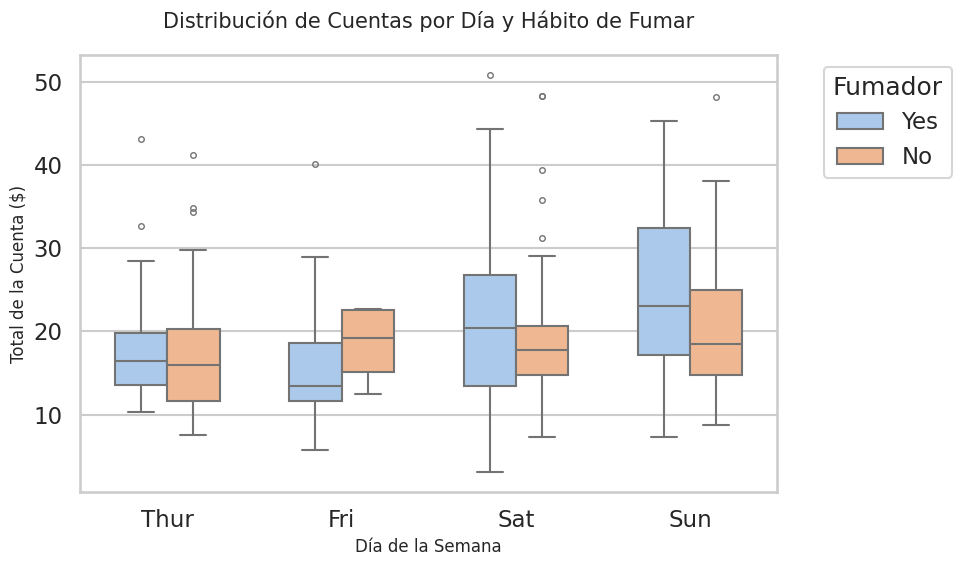

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="pastel", context='talk')

tips = sns.load_dataset('tips')

tips.info()

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=tips,
    x='day',
    y='total_bill',
    hue='smoker',
    fliersize=4,
    width=0.6,
    linewidth=1.5
)


plt.title('Distribución de Cuentas por Día y Hábito de Fumar', fontsize=15, pad=20)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Total de la Cuenta ($)', fontsize=12)

plt.legend(title='Fumador', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42) # Semilla de creacion aleatoria
n = 3000 # Para crear valores aleatorios

comunidades = ['Andalucía', 'Cataluña', 'C. Valenciana', 'Madrid',
               'Baleares', 'Canarias', 'País Vasco', 'Galicia']
tipos = ['Hotel', 'Apartamento', 'Hostal', 'Rural']
origenes = ['Nacional', 'UE', 'Internacional']

# --- Arrays NumPy base ---
fechas = pd.date_range('2024-01-01', '2024-12-31', periods=n)
comunidad_arr = np.random.choice(comunidades, n, p=[0.20, 0.18, 0.15, 0.14, 0.12, 0.10, 0.06, 0.05])
tipo_arr = np.random.choice(tipos, n, p=[0.40, 0.30, 0.15, 0.15])
origen_arr = np.random.choice(origenes, n, p=[0.45, 0.35, 0.20])

noches = np.random.randint(1, 15, n).astype(float)
precio_noche = np.round(np.random.uniform(30, 250, n), 2)
ocupacion_pct = np.round(np.clip(np.random.normal(72, 18, n), 10, 100), 1)
valoracion = np.round(np.clip(np.random.normal(7.5, 1.5, n), 1, 10), 1)

# Inyectar nulos (~5 %)
nulos_noches = np.random.choice(n, 80, replace=False)
nulos_precio = np.random.choice(n, 100, replace=False)
nulos_valoracion = np.random.choice(n, 60, replace=False)
noches[nulos_noches] = np.nan
precio_noche[nulos_precio] = np.nan
valoracion[nulos_valoracion] = np.nan

# Construir DataFrame
reservas = pd.DataFrame({
    'fecha': fechas,
    'comunidad': comunidad_arr,
    'tipo_alojamiento': tipo_arr,
    'noches': noches,
    'precio_noche': precio_noche,
    'ocupacion_pct': ocupacion_pct,
    'valoracion': valoracion,
    'origen_turista': origen_arr
})

# Duplicados intencionados (~3 %)
duplicados = reservas.sample(90, random_state=42)
reservas = pd.concat([reservas, duplicados], ignore_index=True)

print("Dataset generado correctamente")
print(f"Forma: {reservas.shape}")
print(f"Columnas: {list(reservas.columns)}")
print(reservas.head())

Dataset generado correctamente
Forma: (3090, 8)
Columnas: ['fecha', 'comunidad', 'tipo_alojamiento', 'noches', 'precio_noche', 'ocupacion_pct', 'valoracion', 'origen_turista']
                          fecha  comunidad tipo_alojamiento  noches  \
0 2024-01-01 00:00:00.000000000   Cataluña      Apartamento     5.0   
1 2024-01-01 02:55:15.505168389    Galicia           Hostal     2.0   
2 2024-01-01 05:50:31.010336778   Baleares            Hotel    12.0   
3 2024-01-01 08:45:46.515505168     Madrid      Apartamento    13.0   
4 2024-01-01 11:41:02.020673557  Andalucía      Apartamento     1.0   

   precio_noche  ocupacion_pct  valoracion origen_turista  
0        107.69           53.2         6.1             UE  
1        239.04           60.0         6.9       Nacional  
2        157.27           66.8         8.1  Internacional  
3        110.47           90.5         6.4             UE  
4        238.91           72.7         8.1       Nacional  


# 1. Generación del dataset con NumPy

Crear arrays con np.random y construir datos estructurados con operaciones vectorizadas

El primer paso del análisis es generar el dataset sintético de reservas turísticas. Usarás NumPy para crear arrays aleatorios controlados con seed, aplicar distribuciones (uniform, normal, randint) y manipular los datos con operaciones vectorizadas como clip y round.

1
Fija la semilla con np.random.seed(42) para reproducibilidad

2
Crea un array de 3.000 comunidades con np.random.choice y probabilidades desiguales

3
Genera precios con np.random.uniform(30, 250, n) y redondea con np.round

4
Genera ocupación con np.random.normal(72, 18, n) y limita entre 10-100 con np.clip

5
Muestra la forma y los primeros valores de cada array

In [ ]:
import numpy as np

p_dist = [0.25, 0.20, 0.15, 0.10, 0.10, 0.10, 0.05, 0.05]
data_comunidades = np.random.choice(comunidades, size=n, p=p_dist) # Apartir del porcentaje indica la cantidad que quieres que salga un dato

precios = np.round(np.random.uniform(30, 250, n), 2) #Uniform: genera números aleatorios distribuidos uniformemente

ocupacion = np.random.normal(72, 18, n)
ocupacion = np.clip(ocupacion, 10, 100).astype(int) #Clip: limitar (recortar) los valores de un arreglo. De entre 4 - 10 y tranforma los datos por debajo o arriba a 4 o 10

valoraciones = np.random.normal(7.5, 1.5, n)
valoraciones = np.round(np.clip(valoraciones, 1, 10), 1)

print(f"Dataset generado con {n} registros.\n")
print(f"Forma de 'precios': {precios.shape}")
print(f"Primeras 5 Comunidades: {data_comunidades[:5]}")
print(f"Primeros 5 Precios:     {precios[:5]}")
print(f"Primeras 5 Ocupaciones: {ocupacion[:5]}%")
print(f"Primeras 5 Valoraciones: {valoraciones[:5]}")

Dataset generado con 3000 registros.

Forma de 'precios': (3000,)
Primeras 5 Comunidades: ['Madrid' 'Baleares' 'Madrid' 'Andalucía' 'Cataluña']
Primeros 5 Precios:     [173.74 113.77 118.18 140.4   81.43]
Primeras 5 Ocupaciones: [100  47  51  87  66]%
Primeras 5 Valoraciones: [7.3 5.8 7.2 7.6 6.2]


# Carga en Pandas y exploración

Ya tienes los arrays NumPy. Ahora debes convertirlos en un DataFrame de Pandas y explorar la estructura del dataset con las herramientas básicas: head(), info(), describe(), shape y dtypes. Esto te permitirá entender qué tienes antes de limpiarlo.

1
Examina el DataFrame reservas con head() y tail()

2
Usa shape para ver filas y columnas

3
Ejecuta info() para ver tipos y valores nulos

4
Aplica describe() a las columnas numéricas

5
Muestra los value_counts() de comunidad y tipo_alojamiento




In [ ]:
print("--- Primeras 5 filas ---")
print(reservas.head())
print("\n--- Últimas 5 filas ---")
print(reservas.tail()) #5 ultimas por defecto si no tail(?) y el numero que tu quieras

print(f"\nForma del DataFrame (filas, columnas): {reservas.shape}")

print("\n--- Información general del dataset ---")
reservas.info()

print("\n--- Estadísticas descriptivas ---")
print(reservas.describe())

print("\n--- Conteo por Comunidad ---")
print(reservas['comunidad'].value_counts())

print("\n--- Conteo por Tipo de Alojamiento ---")
print(reservas['tipo_alojamiento'].value_counts())

--- Primeras 5 filas ---
                          fecha  comunidad tipo_alojamiento  noches  \
0 2024-01-01 00:00:00.000000000   Cataluña      Apartamento     5.0   
1 2024-01-01 02:55:15.505168389    Galicia           Hostal     2.0   
2 2024-01-01 05:50:31.010336778   Baleares            Hotel    12.0   
3 2024-01-01 08:45:46.515505168     Madrid      Apartamento    13.0   
4 2024-01-01 11:41:02.020673557  Andalucía      Apartamento     1.0   

   precio_noche  ocupacion_pct  valoracion origen_turista  
0        107.69           53.2         6.1             UE  
1        239.04           60.0         6.9       Nacional  
2        157.27           66.8         8.1  Internacional  
3        110.47           90.5         6.4             UE  
4        238.91           72.7         8.1       Nacional  

--- Últimas 5 filas ---
                             fecha comunidad tipo_alojamiento  noches  \
3085 2024-01-18 12:37:12.744248082  Cataluña            Hotel     1.0   
3086 2024-11-03 0

# Limpieza de datos


La exploración ha revelado duplicados (~90 filas extra) y nulos en noches, precio_noche y valoracion. Debes limpiar el dataset eliminando duplicados y rellenando nulos con estrategias apropiadas: mediana para numéricos (robusta frente a outliers) y moda para categóricos.

1
Cuenta los duplicados con duplicated().sum()

2
Elimínalos con drop_duplicates() y verifica la nueva forma

3
Muestra el total de nulos por columna con isnull().sum()

4
Rellena nulos numéricos con la mediana y categóricos con la moda

5
Confirma que no quedan nulos con isnull().sum().sum()

In [ ]:
total_duplicados = reservas.duplicated().sum() # Numpy: Unique o pillas los index
print(f"Total de filas duplicadas detectadas: {total_duplicados}")

reservas = reservas.drop_duplicates().reset_index(drop=True) # Quitas los duplicados y reseteas los index
print(f"Nueva forma del DataFrame tras eliminar duplicados: {reservas.shape}")

print("\nNulos por columna antes de limpiar:")
print(reservas.isnull().sum()) # Los nulos que existian en cada columna

# Numéricos: Mediana (más robusta)
reservas['noches'] = reservas['noches'].fillna(reservas['noches'].median()) # Rellenar los nulos de la columna por la media
reservas['precio_noche'] = reservas['precio_noche'].fillna(reservas['precio_noche'].median())
reservas['valoracion'] = reservas['valoracion'].fillna(reservas['valoracion'].median())

# Categóricos (en caso de que hubiera): Moda
reservas['comunidad'] = reservas['comunidad'].fillna(reservas['comunidad'].mode()[0])

print(f"\nTotal de nulos en el dataset: {reservas.isnull().sum().sum()}")
print(f"Moda: {reservas['comunidad'].mode()[0]}")

Total de filas duplicadas detectadas: 90
Nueva forma del DataFrame tras eliminar duplicados: (3000, 8)

Nulos por columna antes de limpiar:
fecha                 0
comunidad             0
tipo_alojamiento      0
noches               80
precio_noche        100
ocupacion_pct         0
valoracion           60
origen_turista        0
dtype: int64

Total de nulos en el dataset: 0
Moda: Andalucía


Feature engineering temporal
# Nueva sección

Con el dataset limpio, es momento de enriquecerlo. Extrae información temporal de la columna fecha (mes, trimestre, día de la semana) y crea columnas calculadas como ingreso_total y temporada turística usando operaciones vectorizadas de NumPy y Pandas.

1
Convierte fecha a datetime si no lo es ya con pd.to_datetime()

2
Extrae mes, trimestre y día de la semana con .dt

3
Crea la columna ingreso_total = noches * precio_noche

4
Clasifica la temporada (alta: jun-sep, media: mar-may y oct, baja: resto) con np.select

5
Muestra las nuevas columnas con head()

In [ ]:
reservas['fecha'] = pd.to_datetime(reservas['fecha'])

reservas['mes'] = reservas['fecha'].dt.month #Para optener el mes
reservas['trimestre'] = reservas['fecha'].dt.quarter #Para optener el trimestre
reservas['dia_semana'] = reservas['fecha'].dt.day_name() #Para optener el nombre del dia

reservas['ingreso_total'] = reservas['noches'] * reservas['precio_noche']

condiciones = [
    (reservas['mes'].between(6, 9)),                       # Alta: Jun-Sep
    (reservas['mes'].isin([3, 4, 5, 10])),                # Media: Mar-May y Oct
    (reservas['mes'].isin([1, 2, 11, 12]))                # Baja: Resto
]
valores = ['Alta', 'Media', 'Baja']

reservas['temporada'] = np.select(condiciones, valores, default='Baja')

print("--- Columnas generadas (Primeras 5 filas) ---")
print(reservas[['fecha', 'mes', 'trimestre', 'ingreso_total', 'temporada']].head())

--- Columnas generadas (Primeras 5 filas) ---
                          fecha  mes  trimestre  ingreso_total temporada
0 2024-01-01 00:00:00.000000000    1          1         538.45      Baja
1 2024-01-01 02:55:15.505168389    1          1         478.08      Baja
2 2024-01-01 05:50:31.010336778    1          1        1887.24      Baja
3 2024-01-01 08:45:46.515505168    1          1        1436.11      Baja
4 2024-01-01 11:41:02.020673557    1          1         238.91      Baja


# Filtrado y selección

El Ministerio quiere varios cortes del dataset: reservas de lujo en temporada alta, destinos más económicos, y comparativas entre comunidades específicas. Debes dominar el filtrado booleano con &, | y ~ para extraer subconjuntos relevantes.

1
Filtra reservas de lujo: precio_noche > 180 y temporada Alta

2
Filtra destinos económicos: precio_noche < 60 y valoracion >= 8

3
Compara Baleares vs Canarias en temporada alta

4
Cuenta reservas por tipo de alojamiento en cada filtro

5
Calcula el ingreso medio de cada segmento

In [ ]:
lujo_alta = reservas[(reservas['precio_noche'] > 180) & (reservas['temporada'] == 'Alta')]

economico_top = reservas[(reservas['precio_noche'] < 60) & (reservas['valoracion'] >= 8)] # Saber el economico to por temporada alta y baja es decir agrupado

agrupado = reservas.groupby(['comunidad', 'temporada'])['ingreso_total'].mean()

print(agrupado.loc[:, ['Alta', 'Baja']]) #Mostrar de todos los que hay lo de alta y baja

islas_alta = reservas[
    (reservas['comunidad'].isin(['Baleares', 'Canarias'])) & # Para buscar las que no son Baleares y Canarias ~reservas
    (reservas['temporada'] == 'Alta')
]

print("Distribución de alojamientos en segmento Lujo-Alta:")
print(lujo_alta['tipo_alojamiento'].value_counts())

print(f"\nIngreso medio Lujo-Alta: {lujo_alta['ingreso_total'].mean():.2f}€")
print(f"Ingreso medio Económico-Top: {economico_top['ingreso_total'].mean():.2f}€")
print(f"Ingreso medio Islas (Alta): {islas_alta['ingreso_total'].mean():.2f}€")

comunidad      temporada
Andalucía      Alta         1007.406010
               Baja         1039.707067
Baleares       Alta          984.494370
               Baja         1131.356929
C. Valenciana  Alta         1090.381184
               Baja         1117.807226
Canarias       Alta          968.244587
               Baja         1104.188778
Cataluña       Alta         1167.817407
               Baja         1011.206404
Galicia        Alta          972.530556
               Baja         1140.237213
Madrid         Alta         1116.376405
               Baja         1028.019675
País Vasco     Alta          937.730000
               Baja         1167.851452
Name: ingreso_total, dtype: float64
Distribución de alojamientos en segmento Lujo-Alta:
tipo_alojamiento
Hotel          121
Apartamento     92
Rural           47
Hostal          44
Name: count, dtype: int64

Ingreso medio Lujo-Alta: 1575.94€
Ingreso medio Económico-Top: 352.40€
Ingreso medio Islas (Alta): 976.73€


# Agrupación y agregación

El informe ejecutivo necesita tablas resumen: ingreso medio por comunidad y tipo, pivot table de ocupación por comunidad y trimestre, y un ranking de las comunidades con mayor facturación. Domina groupby y pivot_table para transformar datos granulares en información ejecutiva.

1
Agrupa por comunidad y calcula media de precio, ocupación y valoración

2
Agrupa por comunidad y tipo_alojamiento, calcula ingreso total y conteo

3
Crea una pivot_table: comunidad × trimestre, valores = ocupacion_pct, aggfunc = mean

4
Ordena comunidades por ingreso total descendente con sort_values()

5
Muestra el top 3 con nlargest()

In [ ]:
resumen_comunidades = reservas.groupby('comunidad')[['precio_noche', 'ocupacion_pct', 'valoracion']].mean()
print("--- Resumen por Comunidad ---")
print(resumen_comunidades.round(2))

ranking_tipo = reservas.groupby(['comunidad', 'tipo_alojamiento'])['ingreso_total'].agg(['sum', 'count'])

pivot_ocup = pd.pivot_table(reservas,
                            values='ocupacion_pct',
                            index='comunidad',
                            columns='trimestre',
                            aggfunc='mean').round(1)
print("\n--- Ocupación Media por Trimestre (Pivot) ---")
print(pivot_ocup)

ranking_ingresos = reservas.groupby('comunidad')['ingreso_total'].sum().sort_values(ascending=False)

top_3 = ranking_ingresos.nlargest(3)
print("\n--- Top 3 Comunidades por Ingresos ---")
print(top_3)

--- Resumen por Comunidad ---
               precio_noche  ocupacion_pct  valoracion
comunidad                                             
Andalucía            138.20          70.70        7.59
Baleares             141.01          72.71        7.41
C. Valenciana        142.31          71.10        7.45
Canarias             140.24          73.39        7.57
Cataluña             140.10          71.00        7.39
Galicia              150.47          70.82        7.47
Madrid               139.32          69.88        7.42
País Vasco           148.05          71.48        7.37

--- Ocupación Media por Trimestre (Pivot) ---
trimestre         1     2     3     4
comunidad                            
Andalucía      69.2  70.3  72.1  71.3
Baleares       69.7  74.5  71.8  74.5
C. Valenciana  74.7  68.5  70.8  70.7
Canarias       69.6  74.1  75.5  73.8
Cataluña       69.9  70.8  73.3  70.2
Galicia        71.2  69.0  68.8  73.5
Madrid         71.5  68.3  70.1  69.5
País Vasco     71.1  72.1  71.8

# Visualización de tendencias

El informe necesita un gráfico de evolución temporal. Debes mostrar la ocupación media mensual de las 4 comunidades con más reservas, con líneas diferenciadas por color y marcador. Incluye grid, leyenda y título profesional.

1
Identifica las top 4 comunidades por número de reservas

2
Calcula la ocupación media mensual para cada una con groupby

3
Crea la figura con plt.subplots(figsize=(12, 6))

4
Dibuja una línea por comunidad con colores y marcadores distintos

5
Añade título, etiquetas de ejes, leyenda y grid

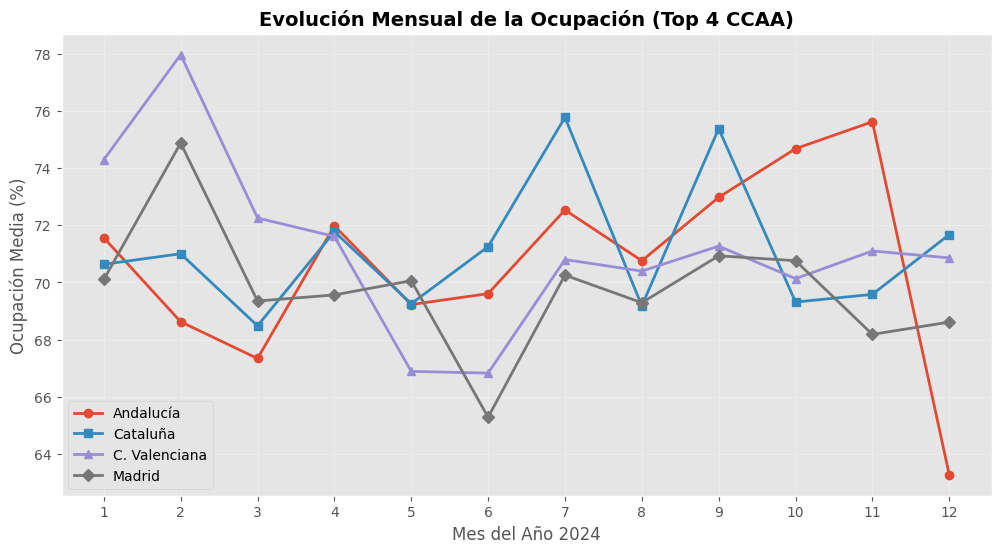

In [ ]:
top4_nombres = reservas['comunidad'].value_counts().head(4).index.tolist()

evolucion = reservas[reservas['comunidad'].isin(top4_nombres)]
evolucion_stats = evolucion.groupby(['mes', 'comunidad'])['ocupacion_pct'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))

marcadores = ['o', 's', '^', 'D']
for i, comunidad in enumerate(top4_nombres):
    ax.plot(evolucion_stats.index, evolucion_stats[comunidad],
            marker=marcadores[i], label=comunidad, linewidth=2)

ax.set_title("Evolución Mensual de la Ocupación (Top 4 CCAA)", fontsize=14, fontweight='bold')
ax.set_xlabel("Mes del Año 2024")
ax.set_ylabel("Ocupación Media (%)")
ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

Scatter: precio vs ocupación

Queremos explorar la relación entre precio y ocupación. ¿Los alojamientos más caros tienen mayor o menor ocupación? Un scatter plot con codificación visual (color = comunidad, tamaño = noches) y una línea de tendencia con np.polyfit revelará esta relación.

1
Toma una muestra de 500 filas para no saturar el gráfico

2
Crea un scatter con color = comunidad (usa un mapa de colores) y tamaño = noches

3
Calcula la línea de tendencia con np.polyfit(grado 1) sobre todo el dataset

4
Dibuja la línea de tendencia con ax.plot()

5
Anota el punto de mayor ingreso con ax.annotate()

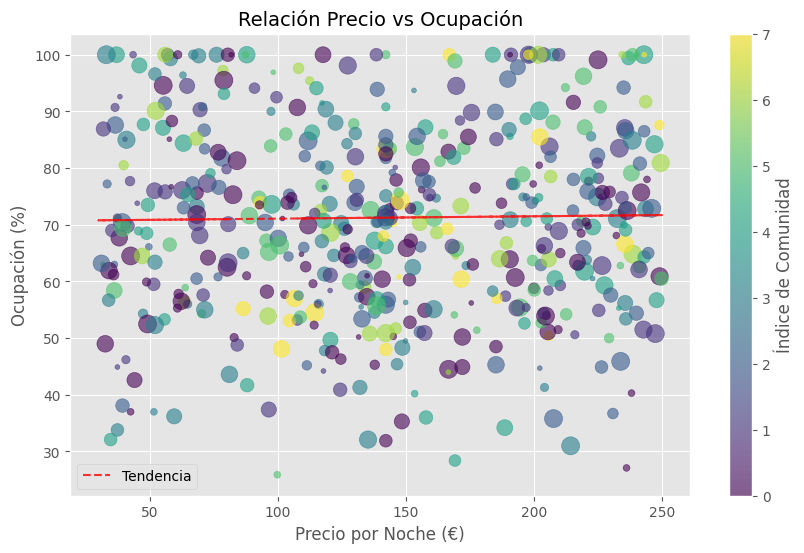

In [ ]:
muestra = reservas.sample(500, random_state=42) #Pillamos 500 muestras de prueba


colores_dict = {cat: i for i, cat in enumerate(comunidades)}
muestra['color_idx'] = muestra['comunidad'].map(colores_dict)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(muestra['precio_noche'], muestra['ocupacion_pct'],
                    c=muestra['color_idx'], s=muestra['noches']*12,
                    alpha=0.6, cmap='viridis')


clean_data = reservas.dropna(subset=['precio_noche', 'ocupacion_pct'])
z = np.polyfit(clean_data['precio_noche'], clean_data['ocupacion_pct'], 1)
p = np.poly1d(z)
ax.plot(clean_data['precio_noche'], p(clean_data['precio_noche']), "r--", alpha=0.8, label="Tendencia")

ax.set_title("Relación Precio vs Ocupación", fontsize=14)
ax.set_xlabel("Precio por Noche (€)")
ax.set_ylabel("Ocupación (%)")
plt.colorbar(scatter, label="Índice de Comunidad")
plt.legend()
plt.show()

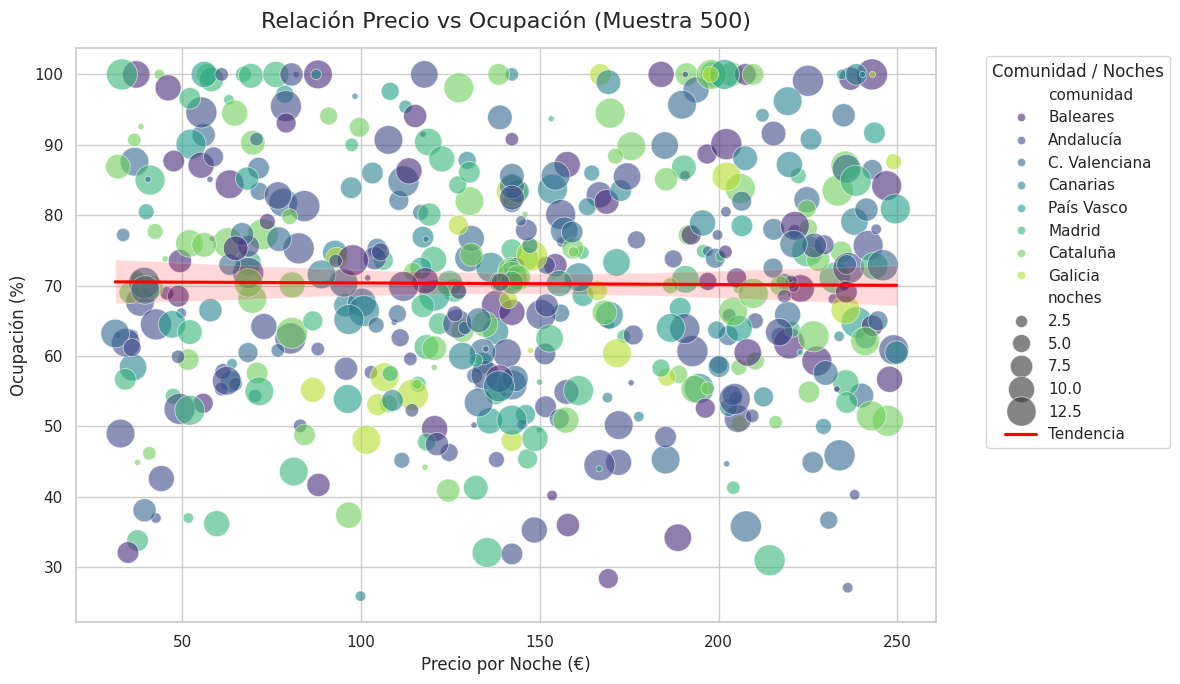

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

muestra = reservas.sample(500, random_state=42)

plt.figure(figsize=(12, 7))

ax = sns.scatterplot(
    data=muestra,
    x='precio_noche',
    y='ocupacion_pct',
    hue='comunidad',
    size='noches',
    sizes=(20, 500),
    alpha=0.6,
    palette='viridis'
)


sns.regplot(
    data=muestra,
    x='precio_noche',
    y='ocupacion_pct',
    scatter=False,
    color='red',
    label="Tendencia"
)

plt.title("Relación Precio vs Ocupación (Muestra 500)", fontsize=16, pad=15)
plt.xlabel("Precio por Noche (€)", fontsize=12)
plt.ylabel("Ocupación (%)", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Comunidad / Noches')

plt.tight_layout()
plt.show()

# Dashboard final con subplots 2x2

El informe ejecutivo para el Ministerio culmina con un dashboard de 4 gráficos: barras horizontales por tipo de alojamiento, gráfico circular por origen del turista, heatmap de la pivot table de ocupación y boxplot de valoraciones por comunidad. Debes crear una composición profesional con subplots.

1
Crea fig, axes = plt.subplots(2, 2, figsize=(14, 10))

2
axes[0,0]: barras horizontales de ingreso medio por tipo de alojamiento

3
axes[0,1]: gráfico circular de proporción por origen del turista

4
axes[1,0]: heatmap (imshow) de la pivot table ocupación × trimestre

5
axes[1,1]: boxplot de valoraciones por las top 4 comunidades

6
Aplica suptitle, tight_layout y un estilo coherente

/tmp/ipython-input-3831632213.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(datos_boxplot, labels=top4)


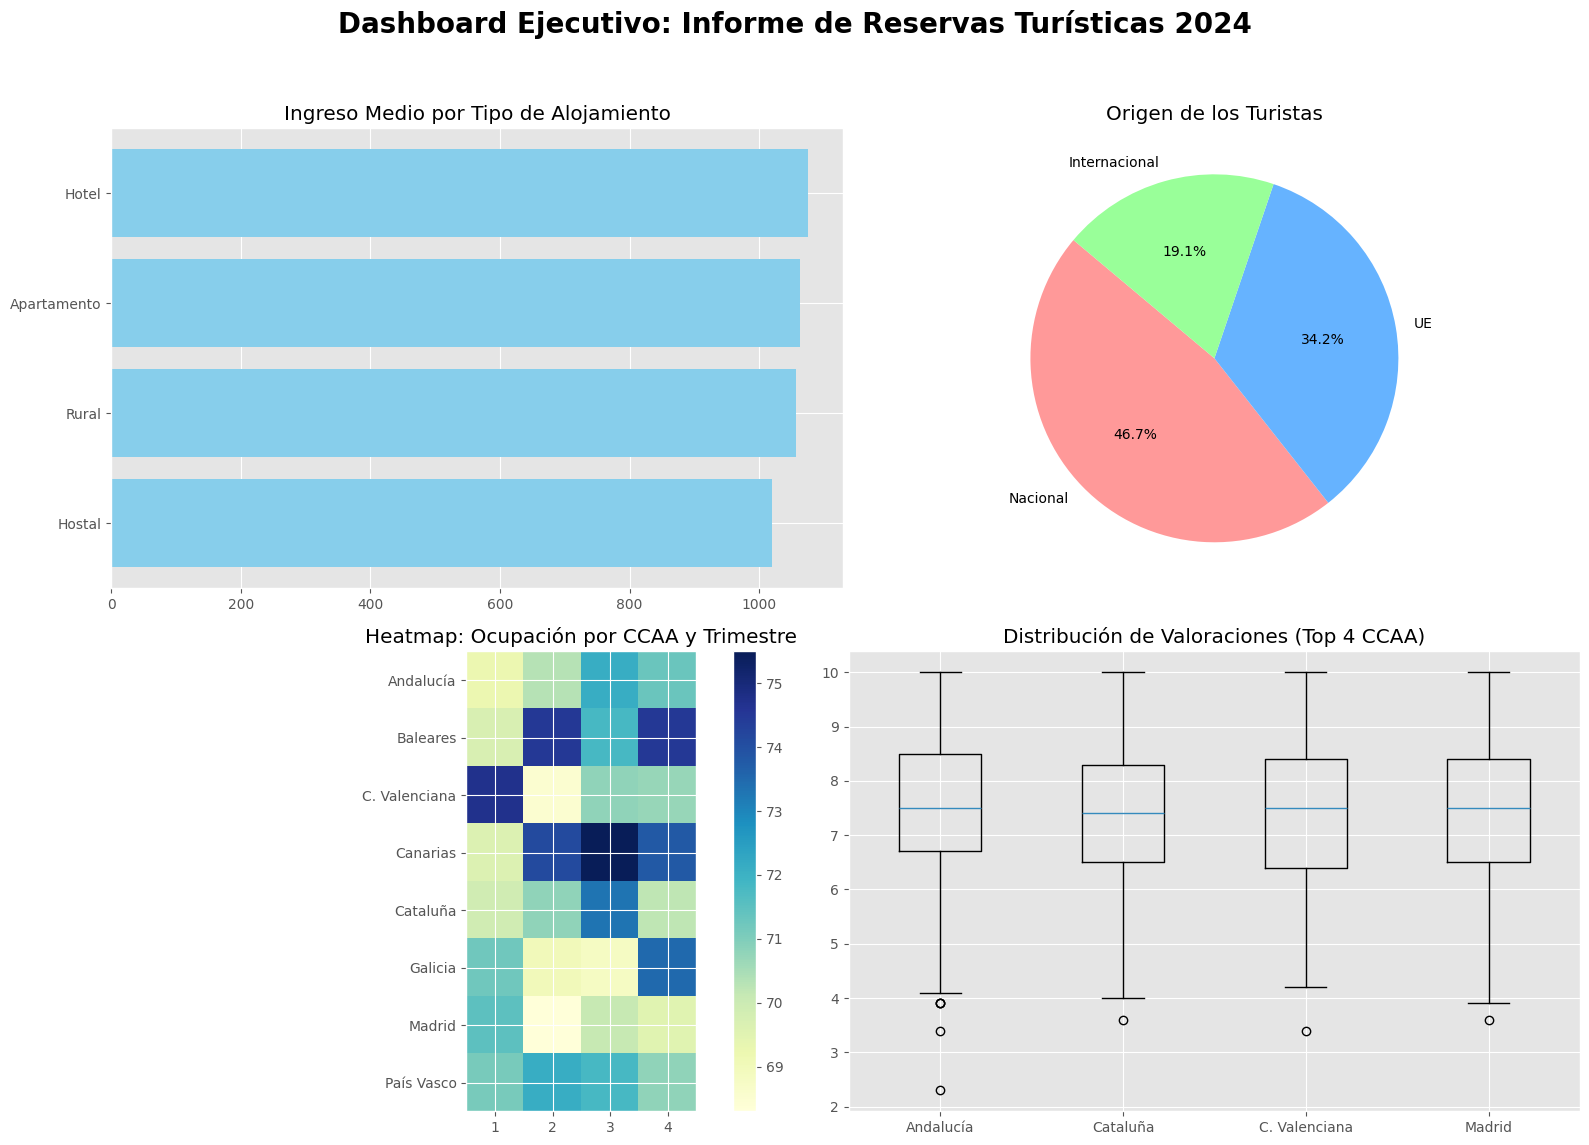

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar datos necesarios
top4 = reservas['comunidad'].value_counts().head(4).index.tolist()

# 1. Crear cuadrícula 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.style.use('ggplot')

# 2. Subplot [0,0]: Barras horizontales — ingreso medio por tipo
ingreso_tipo = reservas.groupby('tipo_alojamiento')['ingreso_total'].mean().sort_values()
axes[0,0].barh(ingreso_tipo.index, ingreso_tipo.values, color='skyblue')
axes[0,0].set_title("Ingreso Medio por Tipo de Alojamiento")

# 3. Subplot [0,1]: Pie — proporción por origen del turista
origen_counts = reservas['origen_turista'].value_counts()
axes[0,1].pie(origen_counts, labels=origen_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
axes[0,1].set_title("Origen de los Turistas")

# 4. Subplot [1,0]: Heatmap de la pivot table
im = axes[1,0].imshow(pivot_ocup, cmap='YlGnBu')
axes[1,0].set_title("Heatmap: Ocupación por CCAA y Trimestre")
# Añadir etiquetas a los ejes del heatmap
axes[1,0].set_xticks(np.arange(len(pivot_ocup.columns)))
axes[1,0].set_yticks(np.arange(len(pivot_ocup.index)))
axes[1,0].set_xticklabels(pivot_ocup.columns)
axes[1,0].set_yticklabels(pivot_ocup.index)
plt.colorbar(im, ax=axes[1,0])

# 5. Subplot [1,1]: Boxplot — valoraciones top 4 CCAA
datos_boxplot = [reservas[reservas['comunidad'] == c]['valoracion'] for c in top4]
axes[1,1].boxplot(datos_boxplot, labels=top4)
axes[1,1].set_title("Distribución de Valoraciones (Top 4 CCAA)")

# 6. Título general y ajuste
plt.suptitle("Dashboard Ejecutivo: Informe de Reservas Turísticas 2024", fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()